# ML-1: Price Prediction Model

## Milestone 2

This notebook trains and compares multiple machine learning models for product price prediction.

Models used:
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost

Evaluation metrics:
- MAE
- RMSE
- R²

GridSearchCV is used for hyperparameter tuning of tree-based models.

In [13]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [14]:
DATA = Path("../data/PricePilot_8_Small_Datasets.xlsx")

sales = pd.read_excel(DATA, sheet_name="02_Historical_Sales")
products = pd.read_excel(DATA, sheet_name="01_Product_Catalog")
competitors = pd.read_excel(DATA, sheet_name="05_Competitor_Prices")
market = pd.read_excel(DATA, sheet_name="08_Market_Economic")

sales["date"] = pd.to_datetime(sales["date"])
competitors["date"] = pd.to_datetime(competitors["date"])
market["date"] = pd.to_datetime(market["date"])

print("Sales:", sales.shape)
print("Products:", products.shape)
print("Competitors:", competitors.shape)
print("Market:", market.shape)

Sales: (1800, 6)
Products: (20, 5)
Competitors: (1800, 4)
Market: (90, 5)


In [15]:
competitor_avg = (
    competitors
    .groupby(["date", "product_id"])["competitor_price"]
    .mean()
    .reset_index()
)

df = sales.merge(
    products,
    on="product_id",
    how="left"
)

df = df.merge(
    competitor_avg,
    on=["date", "product_id"],
    how="left"
)

df = df.merge(
    market,
    on="date",
    how="left"
)

df["competitor_price"] = df["competitor_price"].fillna(
    df["competitor_price"].median()
)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

print("ML Dataset Shape:", df.shape)

df.head()

ML Dataset Shape: (1800, 19)


,date,product_id,selling_price,discount_pct,units_sold,revenue,product_name,category,cost_price,list_price,competitor_price,market_demand_index,demand_growth_rate,inflation_rate,market_search_index,year,month,day,day_of_week
0,2026-05-01,P001,21420.75,5,7,149945.26,Product 01,Running Shoes,15607.06,22548.16,23838.893333,1.171,-0.013,0.068,2716,2026,5,1,4
1,2026-05-02,P001,19165.94,15,9,172493.42,Product 01,Running Shoes,15607.06,22548.16,23838.893333,0.992,0.034,0.050,1070,2026,5,2,5
2,2026-05-03,P001,22548.16,0,9,202933.44,Product 01,Running Shoes,15607.06,22548.16,23838.893333,1.007,0.066,0.050,1733,2026,5,3,6
3,2026-05-04,P001,22548.16,0,8,180385.28,Product 01,Running Shoes,15607.06,22548.16,23838.893333,1.001,0.082,0.051,2585,2026,5,4,0
4,2026-05-05,P001,22548.16,0,7,157837.12,Product 01,Running Shoes,15607.06,22548.16,23838.893333,1.188,0.012,0.049,3435,2026,5,5,1


## Feature Preparation

The target variable is `selling_price`.

`list_price` and transaction-level `discount_pct` are excluded from the prediction features to reduce direct target leakage.

In [16]:
target = "selling_price"

features = [
    "cost_price",
    "competitor_price",
    "units_sold",
    "market_demand_index",
    "demand_growth_rate",
    "inflation_rate",
    "year",
    "month",
    "day",
    "day_of_week",
    "category"
]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

categorical_features = ["category"]

numeric_features = [
    "cost_price",
    "competitor_price",
    "units_sold",
    "market_demand_index",
    "demand_growth_rate",
    "inflation_rate",
    "year",
    "month",
    "day",
    "day_of_week"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "category",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1440, 11)
Testing: (360, 11)


## Model Training and Hyperparameter Tuning

Four models are compared.

GridSearchCV is applied to:
- Random Forest
- Gradient Boosting
- XGBoost

Linear Regression is used as a baseline model.

In [17]:
# Model Training and Hyperparameter Tuning

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )
}

param_grids = {
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [6, 8, None],
        "model__min_samples_split": [2, 5]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    }
}

results = []
best_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    if name in param_grids:

        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=5,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train, y_train)

        fitted_model = grid.best_estimator_

        print("\n" + "=" * 60)
        print(name)
        print("Best Parameters:")
        print(grid.best_params_)
        print("Best CV MAE:", -grid.best_score_)

    else:

        pipeline.fit(X_train, y_train)
        fitted_model = pipeline

    predictions = fitted_model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    best_models[name] = fitted_model

    print("Test MAE:", round(mae, 2))
    print("Test RMSE:", round(rmse, 2))
    print("Test R2:", round(r2, 4))

Test MAE: 1387.14
Test RMSE: 1823.99
Test R2: 0.982
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/adityakumar/PricePilot-AI-/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/adityakumar/PricePilot-AI-/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/adityakumar/PricePilot-AI-/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



Random Forest
Best Parameters:
{'model__max_depth': 6, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV MAE: 1115.5978508944706
Test MAE: 1064.92
Test RMSE: 1487.37
Test R2: 0.9881
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Gradient Boosting
Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV MAE: 1120.854937344139
Test MAE: 1039.24
Test RMSE: 1441.6
Test R2: 0.9888
Fitting 5 folds for each of 8 candidates, totalling 40 fits

XGBoost
Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV MAE: 1123.9459714152017
Test MAE: 1035.96
Test RMSE: 1437.13
Test R2: 0.9888


## Model Evaluation

In [18]:
# Model Evaluation

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(results_df.round(2))

best_model_name = results_df.loc[0, "Model"]
best_model = best_models[best_model_name]

print("\nBest Model:", best_model_name)

,Model,MAE,RMSE,R2
0,XGBoost,1035.96,1437.13,0.99
1,Gradient Boosting,1039.24,1441.60,0.99
2,Random Forest,1064.92,1487.37,0.99
3,Linear Regression,1387.14,1823.99,0.98



Best Model: XGBoost


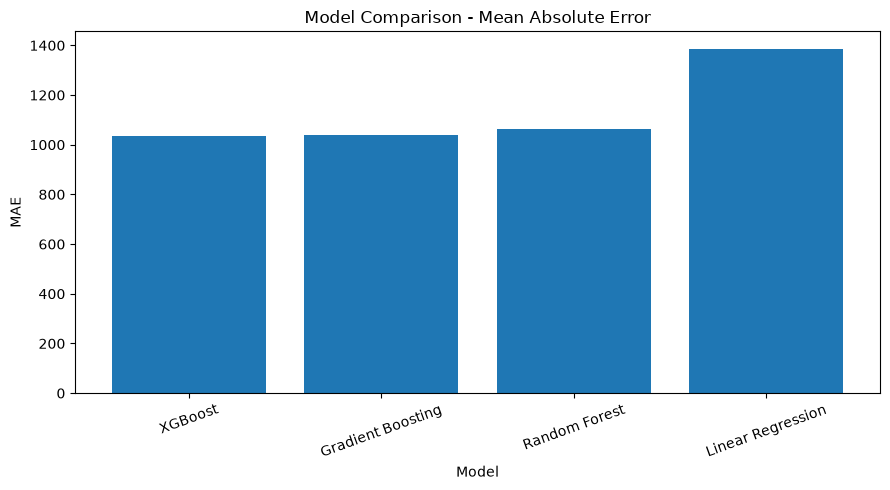

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison - Mean Absolute Error")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

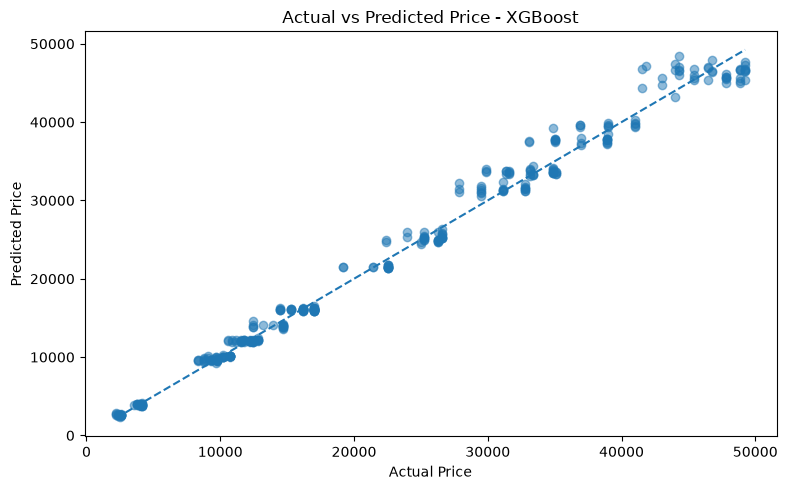

In [20]:
predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]

plt.plot(
    lims,
    lims,
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(
    f"Actual vs Predicted Price - {best_model_name}"
)

plt.tight_layout()
plt.show()

## Save Best Model

In [21]:
MODEL_DIR = Path("../backend/app/ml/saved_models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    best_model,
    MODEL_DIR / "price_prediction_model.pkl"
)

results_df.to_csv(
    MODEL_DIR / "model_comparison.csv",
    index=False
)

print("Best model saved successfully!")
print("Model:", best_model_name)

Best model saved successfully!
Model: XGBoost


## Conclusion

Multiple regression models were trained and evaluated using MAE, RMSE and R².

GridSearchCV was used to tune the tree-based models.

The model with the lowest MAE on the test set was selected as the final price prediction model.

The selected model and model comparison results were saved for backend integration.

In [22]:
import sys
import xgboost

print("Python:", sys.executable)
print("XGBoost:", xgboost.__version__)

Python: /Users/adityakumar/PricePilot-AI-/.venv/bin/python
XGBoost: 2.1.1
